<a href="https://colab.research.google.com/github/PavanKumar91829/Student-Performance-EDA/blob/main/Student_Performance_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Innomatics Internship/EDA Task - 1/scores_data.csv')

In [ ]:
df.head()

,Batch,User_ID,Score
0,AI_ELITE_7,uid_149,6 / 7
1,AI_ELITE_7,uid_148,6 / 7
2,AI_ELITE_7,uid_147,7 / 7
3,AI_ELITE_7,uid_146,7 / 7
4,AI_ELITE_7,uid_145,4 / 7


In [ ]:
df.shape

(149, 3)

In [ ]:
df.columns

Index(['Batch ', 'User_ID ', '   Score   '], dtype='object')

### Renaming columns

In [ ]:
df.columns=df.columns.str.strip()
df.columns

Index(['Batch', 'User_ID', 'Score'], dtype='object')

### Fixing the Data Types of Columns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Batch    149 non-null    object
 1   User_ID  149 non-null    object
 2   Score    149 non-null    object
dtypes: object(3)
memory usage: 3.6+ KB


In [ ]:
df['Batch'].unique()

array(['AI_ELITE_7', 'AI_ELITE_6', 'AI_ELITE_4'], dtype=object)

In [ ]:
df["score_obtained"] = df['Score'].apply(lambda x: int(x.split('/')[0].strip()))

In [ ]:
df['Score_Percent'] = (df['score_obtained'] / 7) * 100

In [ ]:
df.head()

,Batch,User_ID,Score,score_obtained,Score_Percent
0,AI_ELITE_7,uid_149,6 / 7,6,85.714286
1,AI_ELITE_7,uid_148,6 / 7,6,85.714286
2,AI_ELITE_7,uid_147,7 / 7,7,100.000000
3,AI_ELITE_7,uid_146,7 / 7,7,100.000000
4,AI_ELITE_7,uid_145,4 / 7,4,57.142857


In [ ]:
df.drop(columns=["Score"],inplace=True)

In [ ]:
df.head()

,Batch,User_ID,score_obtained,Score_Percent
0,AI_ELITE_7,uid_149,6,85.714286
1,AI_ELITE_7,uid_148,6,85.714286
2,AI_ELITE_7,uid_147,7,100.000000
3,AI_ELITE_7,uid_146,7,100.000000
4,AI_ELITE_7,uid_145,4,57.142857


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Batch           149 non-null    object 
 1   User_ID         149 non-null    object 
 2   score_obtained  149 non-null    int64  
 3   Score_Percent   149 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.8+ KB


In [ ]:
df.describe()

,score_obtained,Score_Percent
count,149.000000,149.000000
mean,4.382550,62.607862
std,1.592199,22.745705
min,0.000000,0.000000
25%,3.000000,42.857143
50%,4.000000,57.142857
75%,5.000000,71.428571
max,7.000000,100.000000


In [ ]:
# Observations
# --> Scores ranges from 0 to 7.
# --> The average score is 4.38 out of 7 (~62.6%), while the median is 4 (57.1%). Mean > median, so the distribution is slightly right-skewed
# --> The interquartile range is 3 to 5 (≈43%–71%)

In [ ]:
df.describe(include='object')

,Batch,User_ID
count,149,149
unique,3,149
top,AI_ELITE_7,uid_149
freq,53,1


In [ ]:
# Observations
# --> There are only 3 batches, and the largest one (AI_ELITE_7) which has 53 records out of 149 users.
# --> 149 unique users for 149 records means one observation per user. No repeat measurements.

In [ ]:
df.isnull().sum()

,0
Batch,0
User_ID,0
score_obtained,0
Score_Percent,0


### Check batch size

In [ ]:
df['Batch'].value_counts()

,count
Batch,
AI_ELITE_7,53
AI_ELITE_6,48
AI_ELITE_4,48


### Univariate Analysis

#### Numerical(continuous)

In [ ]:
def cont_vis_analysis(data,col):
  ## visualisation of continuous numerical variable
  fig,axes=plt.subplots(1,3,figsize=(8,3),layout='constrained')
  fig.suptitle('Continuous Data Distributions')

  axes[0].set_title('Histogram')
  sns.histplot(data[col],ax=axes[0])

  axes[1].set_title('KDE plot')
  sns.kdeplot(data[col],ax=axes[1])

  axes[2].set_title('Boxplot')
  sns.boxplot(data[col],ax=axes[2])
  axes[2].set_xlabel(col)


  fig.show()

def cont_non_vis_analysis(data,col):
  ## Non visual analaysis of continuous numerical data
  series=data[col]
  print(series.agg(['count','min','max','mean','median','var','std','skew','kurt']).round(2))
  print()

count     149.00
min         0.00
max         7.00
mean        4.38
median      4.00
var         2.54
std         1.59
skew       -0.18
kurt       -0.24
Name: score_obtained, dtype: float64



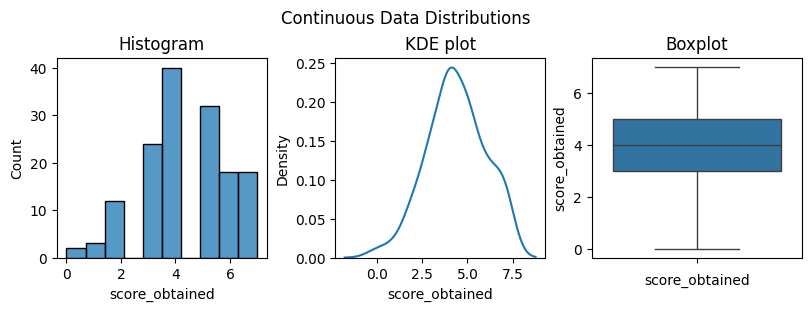

In [ ]:
cont_vis_analysis(df,'score_obtained')
cont_non_vis_analysis(df,'score_obtained')

count     149.00
min         0.00
max       100.00
mean       62.61
median     57.14
var       517.37
std        22.75
skew       -0.18
kurt       -0.24
Name: Score_Percent, dtype: float64



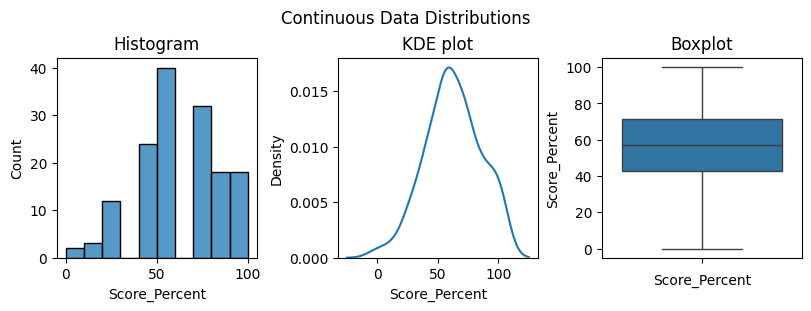

In [ ]:
cont_vis_analysis(df,'Score_Percent')
cont_non_vis_analysis(df,'Score_Percent')

In [ ]:
# Observations
# --> Skewness value (−0.18) indicates the distribution is nearly symmetric with a very little left tail.

#### categorical variables / descrete numerical variables

In [ ]:
def catg_disc_analysis(data,col):
  print("Value Counts for ",col)
  print(data[col].value_counts())
  print("Null values =",data[col].isna().sum())
  fig,axes=plt.subplots(1,2,figsize=(8,6),layout='constrained')
  fig.suptitle('Categorical / Discrete Num Data Distributions')

  axes[0].set_title('Bar Plot')
  sns.countplot(x=col,data=data,ax=axes[0])

  axes[1].set_title('Pie Chart')
  vc_data=data[col].value_counts()
  axes[1].pie(vc_data,labels=vc_data.index,autopct='%1.1f%%')
  fig.show()

Value Counts for  Batch
Batch
AI_ELITE_7    53
AI_ELITE_6    48
AI_ELITE_4    48
Name: count, dtype: int64
Null values = 0


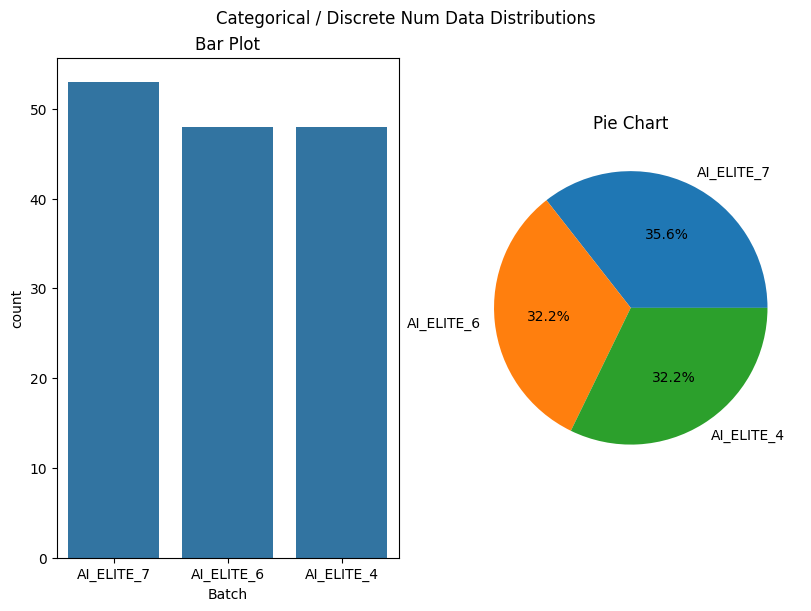

In [ ]:
catg_disc_analysis(df,'Batch')

In [ ]:
# Observations
# --> all three batches are fairly distributed with AI_ELITE_7 is the largest at ~35.6%, but the margin over AI_ELITE_6 and AI_ELITE_4 (~32.2% each) is small.

### Bivariate Analysis

In [ ]:
# cont - cat bivariate
def cont_cat_bivar_analysis(data,cat_col,num_col):
  plt.figure(figsize=(6,4))
  sns.boxplot(x=cat_col,y=num_col,data=data)

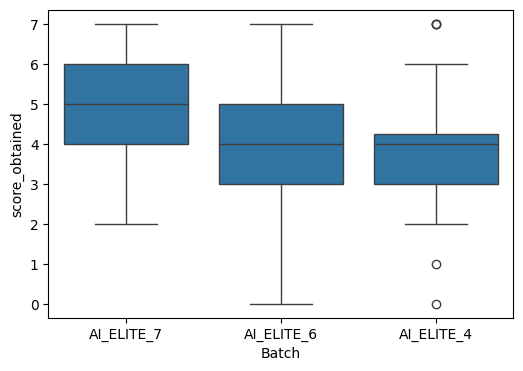

In [ ]:
cont_cat_bivar_analysis(df,'Batch','score_obtained')

In [ ]:
# Observations
# --> Students from 'AI_ELITE_7' generally perform better, because it has higher median score compared to the other batches.
# --> 'AI_ELITE_6' shows more variation in scores, suggesting uneven performance within the batch, whereas AI_ELITE_7 appears more consistent.
# --> There are some outliers in batch 'AI_ELITE_4' indicates it has few extreme low and high scores, indicating that while some students perform very well and others significantly fails.

In [ ]:
batch_summary = (df.groupby('Batch')['score_obtained'].
                 agg(
                     count='count',
                     mean='mean',
                     median='median',
                     std='std',
                     min='min',
                     max='max'
                 ))
batch_summary

,count,mean,median,std,min,max
Batch,,,,,,
AI_ELITE_4,48,3.791667,4.0,1.443376,0,7
AI_ELITE_6,48,4.229167,4.0,1.640441,0,7
AI_ELITE_7,53,5.056604,5.0,1.446682,2,7


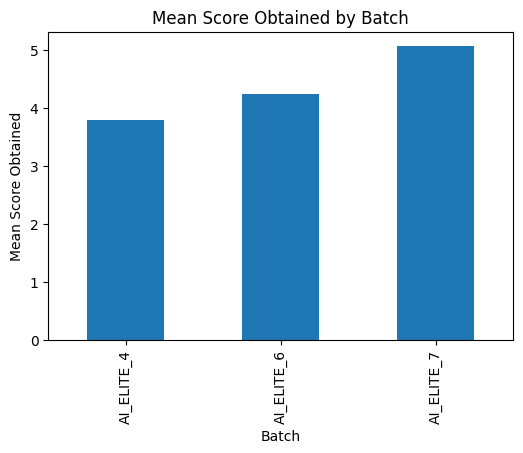

In [ ]:
df.groupby('Batch')['score_obtained'].mean().plot(
    kind='bar',
    figsize=(6,4),
    title='Mean Score Obtained by Batch',
    ylabel='Mean Score Obtained',
    xlabel='Batch'
)
plt.show()


In [ ]:
percent_summary = (
    df.groupby("Batch")["Score_Percent"]
    .mean()
    .reset_index(name="Avg_Percentage")
)
percent_summary

,Batch,Avg_Percentage
0,AI_ELITE_4,54.166667
1,AI_ELITE_6,60.416667
2,AI_ELITE_7,72.237197


In [ ]:
# Observations
# --> The average score increases from AI_ELITE_4(low) to AI_ELITE_7(high), indicating a consistent upward trend in mean performance across batches.
# --> AI_ELITE_7 performs noticeably better than the other two batches on average.

In [ ]:
low_performers = df[df['score_obtained']<=3]

low_performers_per_batch = (
    low_performers.groupby('Batch')['score_obtained'].
    count().
    reset_index(name='count')
)
low_performers_per_batch

,Batch,count
0,AI_ELITE_4,17
1,AI_ELITE_6,15
2,AI_ELITE_7,9


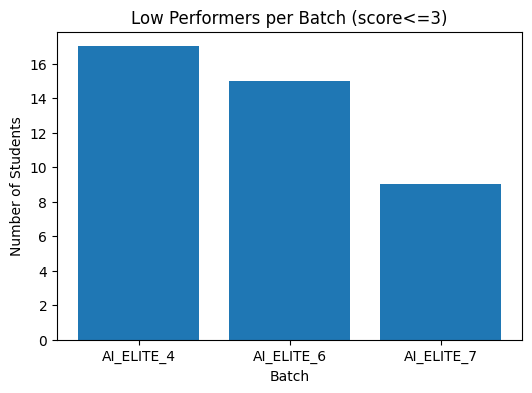

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(
    low_performers_per_batch['Batch'],
    low_performers_per_batch['count']
)
plt.xlabel('Batch')
plt.ylabel('Number of Students')
plt.title('Low Performers per Batch (score<=3)')
plt.show()

In [ ]:
# Observations
# --> AI_ELITE_4 has the highest number of low performers, followed by AI_ELITE_6, while AI_ELITE_7 has the fewest students scoring 3 or below

In [ ]:
# Overall Data Insights
# --> AI_ELITE_4 shows the weakest performance, with the lowest average score and wide variation
# --> AI_ELITE_7 performs the best overall, with the highest average score and fewer low-performing students
# --> AI_ELITE_6 has improvement over AI_ELITE_4, but performance remains uneven with high variability in scores.